# 🎯 Career Path Recommender — End-to-End Deep Learning Pipeline

This notebook trains a **multi-class text classification model** that maps a user's skill set to the most suitable career path.

### Career Labels
| Label | Career |
|---|---|
| 0 | Artificial Intelligence |
| 1 | Data Science |
| 2 | Development |
| 3 | Security |
| 4 | Software Development and Engineering |
| 5 | User Experience (UX) and User Interface (UI) Design |

### Pipeline
1. Data loading & EDA
2. Text preprocessing & tokenisation (TF-IDF)
3. Label encoding
4. Deep Learning model (PyTorch MLP)
5. Training loop with validation
6. Evaluation (accuracy, confusion matrix, classification report)
7. Save model artifacts
8. **Streamlit deployment**
9. **FastAPI deployment**

## Cell 1 — Install Dependencies

In [1]:
# Run once — comment out after first run
!pip install pandas numpy scikit-learn torch openpyxl matplotlib seaborn joblib

## Cell 2 — Imports

In [2]:
import pandas as pd
import numpy as np
import re
import joblib
import json
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print(f"PyTorch version : {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device    : {device}")

PyTorch version : 2.11.0+cu128
Using device    : cuda


## Cell 3 — Load Data

In [ ]:
# ── Change this path to your local file if needed ──────────────────────────
DATA_PATH = "Dataset/Career_Dataset.xlsx"
# ───────────────────────────────────────────────────────────────────────────

df = pd.read_excel(DATA_PATH)
print(f"Dataset shape : {df.shape}")
df.head()

Dataset shape : (4076, 2)


,Career,Skill
0,Software Development and Engineering,"Web Development, Mobile App Development, Artif..."
1,Development,"Web Development, Mobile App Development, Probl..."
2,Data Science,"Data Analysis and Visualization, Deeplearning,..."
3,Development,Web Development
4,Artificial Intelligence,"Deep Learning, Machine Learning, Statistics, D..."


## Cell 4 — Exploratory Data Analysis

=== Class Distribution ===
Career
Development                                            1148
Artificial Intelligence                                 804
Software Development and Engineering                    714
Security                                                580
Data Science                                            558
User Experience (UX) and User Interface (UI) Design     272
Name: count, dtype: int64


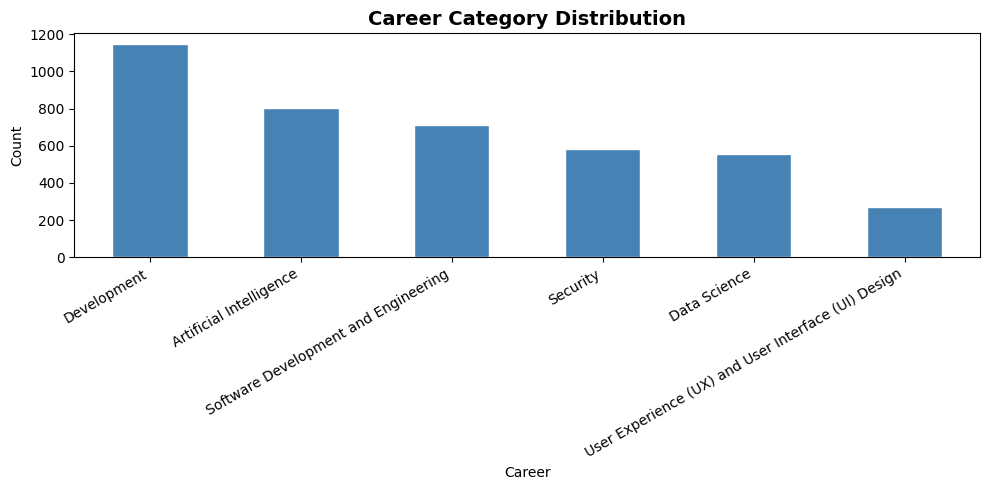


Avg skills per row : 5.9
Max skills per row : 37


In [4]:
print("=== Class Distribution ===")
print(df["Career"].value_counts())

fig, ax = plt.subplots(figsize=(10, 5))
df["Career"].value_counts().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Career Category Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Career")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

# Skill text length distribution
df["skill_len"] = df["Skill"].astype(str).apply(lambda x: len(x.split(",")))
print(f"\nAvg skills per row : {df['skill_len'].mean():.1f}")
print(f"Max skills per row : {df['skill_len'].max()}")

## Cell 5 — Text Preprocessing

In [5]:
def clean_skills(text: str) -> str:
    """Lowercase, strip extra spaces, remove special chars."""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9,\s]", " ", text)   # keep letters, digits, commas
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["cleaned_skills"] = df["Skill"].apply(clean_skills)

print("Before:", df["Skill"].iloc[0])
print("After :", df["cleaned_skills"].iloc[0])

Before: Web Development, Mobile App Development, Artificial Intelligence (AI) and Machine Learning, Problem Solving and Analysis, Cybersecurity, Operating Systems and Networking, Database Development, Data Analysis andVisualization, API Testing, Performance Testing, Statistical Analysis, ROLLING NOISE FILTER, Broadcast Journalism, Computer Network
After : web development, mobile app development, artificial intelligence ai and machine learning, problem solving and analysis, cybersecurity, operating systems and networking, database development, data analysis andvisualization, api testing, performance testing, statistical analysis, rolling noise filter, broadcast journalism, computer network


## Cell 6 — Label Encoding

In [6]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["Career"])

label_map = dict(enumerate(le.classes_))
print("Label mapping:", json.dumps(label_map, indent=2))

NUM_CLASSES = len(le.classes_)

Label mapping: {
  "0": "Artificial Intelligence",
  "1": "Data Science",
  "2": "Development",
  "3": "Security",
  "4": "Software Development and Engineering",
  "5": "User Experience (UX) and User Interface (UI) Design"
}


## Cell 7 — TF-IDF Vectorisation

In [7]:
X_raw = df["cleaned_skills"].values
y     = df["label"].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),     # unigrams + bigrams
    sublinear_tf=True
)
X_train = tfidf.fit_transform(X_train_raw).toarray().astype(np.float32)
X_test  = tfidf.transform(X_test_raw).toarray().astype(np.float32)

print(f"Train : {X_train.shape}   Test : {X_test.shape}")

Train : (3260, 4678)   Test : (816, 4678)


## Cell 8 — Convert to PyTorch Tensors & DataLoaders

In [8]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

BATCH_SIZE = 64

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}   Test batches : {len(test_loader)}")

Train batches : 51   Test batches : 13


## Cell 9 — Deep Learning Model (MLP)

In [9]:
class CareerMLP(nn.Module):
    """Multi-Layer Perceptron for career classification."""

    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            # Block 2
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Block 3
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            # Block 4
            nn.Linear(256, 128),
            nn.ReLU(),
            # Output
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


INPUT_DIM = X_train.shape[1]
model = CareerMLP(INPUT_DIM, NUM_CLASSES).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters : {total_params:,}")

CareerMLP(
  (net): Sequential(
    (0): Linear(in_features=4678, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): ReLU()
    (14): Linear(in_features=128, out_features=6, bias=True)
  )
)

Total parameters : 5,484,678


## Cell 10 — Training Configuration

In [11]:
EPOCHS   = 40
LR       = 1e-3
PATIENCE = 7   # early stopping

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

print("Criterion :", criterion)
print("Optimizer :", optimizer.__class__.__name__)

Criterion : CrossEntropyLoss()
Optimizer : Adam


## Cell 11 — Training Loop

In [12]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_acc = 0.0
patience_counter = 0


def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out  = model(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * len(yb)
            preds  = out.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total   += len(yb)
    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss    += loss.item() * len(yb)
        preds            = out.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total   += len(yb)

    train_loss = running_loss / running_total
    train_acc  = running_correct / running_total
    val_loss, val_acc = evaluate(test_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_acc)

    # ── Early stopping & checkpoint ────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} "
        f"{'  ✅ best' if patience_counter == 0 else ''}"
    )

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

print(f"\nBest Validation Accuracy : {best_val_acc:.4f}")

Epoch 01/40 | Train Loss: 0.5272  Acc: 0.8494 | Val Loss: 1.4375  Acc: 0.4044   ✅ best
Epoch 02/40 | Train Loss: 0.1605  Acc: 0.9574 | Val Loss: 0.2012  Acc: 0.9461   ✅ best
Epoch 03/40 | Train Loss: 0.1150  Acc: 0.9718 | Val Loss: 0.2181  Acc: 0.9485   ✅ best
Epoch 04/40 | Train Loss: 0.0930  Acc: 0.9764 | Val Loss: 0.2166  Acc: 0.9436 
Epoch 05/40 | Train Loss: 0.0727  Acc: 0.9813 | Val Loss: 0.1885  Acc: 0.9522   ✅ best
Epoch 06/40 | Train Loss: 0.0809  Acc: 0.9801 | Val Loss: 0.2141  Acc: 0.9387 
Epoch 07/40 | Train Loss: 0.0821  Acc: 0.9785 | Val Loss: 0.2221  Acc: 0.9485 
Epoch 08/40 | Train Loss: 0.0733  Acc: 0.9798 | Val Loss: 0.2231  Acc: 0.9498 
Epoch 09/40 | Train Loss: 0.0821  Acc: 0.9785 | Val Loss: 0.2044  Acc: 0.9498 
Epoch 10/40 | Train Loss: 0.0635  Acc: 0.9847 | Val Loss: 0.2231  Acc: 0.9498 
Epoch 11/40 | Train Loss: 0.0518  Acc: 0.9844 | Val Loss: 0.2307  Acc: 0.9534   ✅ best
Epoch 12/40 | Train Loss: 0.0535  Acc: 0.9856 | Val Loss: 0.2402  Acc: 0.9485 
Epoch 13/40 

## Cell 12 — Training Curves

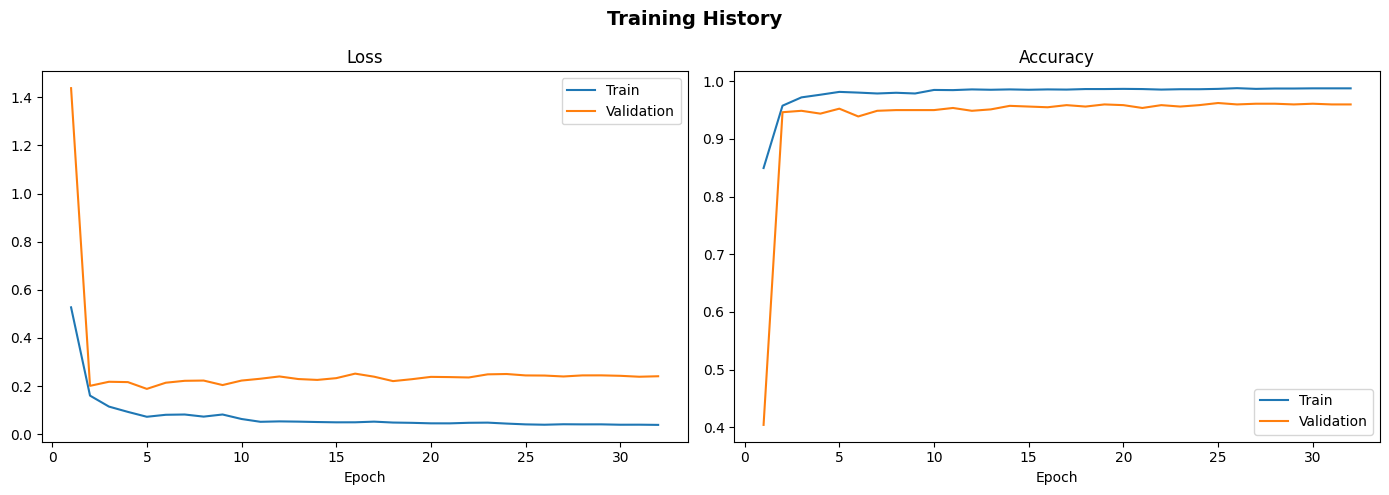

In [13]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train")
axes[0].plot(epochs_ran, history["val_loss"],   label="Validation")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_ran, history["train_acc"], label="Train")
axes[1].plot(epochs_ran, history["val_acc"],   label="Validation")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.suptitle("Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## Cell 13 — Evaluation on Test Set

Test Accuracy : 0.9620

                                                     precision    recall  f1-score   support

                            Artificial Intelligence       0.97      0.98      0.97       161
                                       Data Science       0.96      0.96      0.96       112
                                        Development       0.95      0.99      0.97       230
                                           Security       0.98      0.92      0.95       116
               Software Development and Engineering       0.96      0.92      0.94       143
User Experience (UX) and User Interface (UI) Design       1.00      1.00      1.00        54

                                           accuracy                           0.96       816
                                          macro avg       0.97      0.96      0.96       816
                                       weighted avg       0.96      0.96      0.96       816



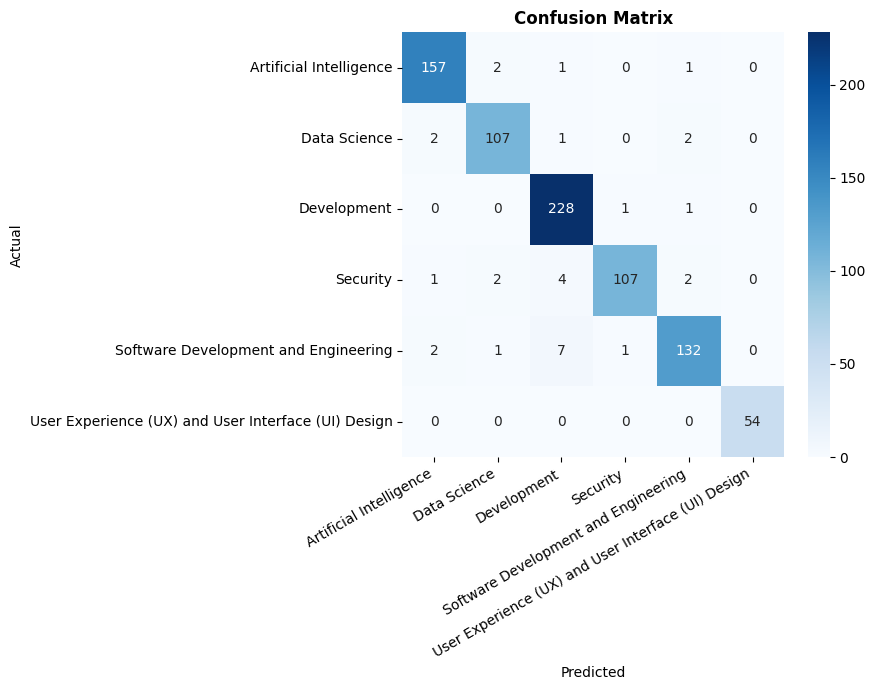

In [14]:
# Load the best checkpoint
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

print(f"Test Accuracy : {accuracy_score(all_true, all_preds):.4f}\n")
print(classification_report(all_true, all_preds, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## Cell 14 — Save All Artifacts

In [15]:
os.makedirs("artifacts", exist_ok=True)

# TF-IDF vectoriser
joblib.dump(tfidf, "artifacts/tfidf_vectorizer.pkl")

# Label encoder
joblib.dump(le, "artifacts/label_encoder.pkl")

# Model weights
import shutil
shutil.copy("best_model.pt", "artifacts/best_model.pt")

# Model metadata
meta = {
    "input_dim":   INPUT_DIM,
    "num_classes": NUM_CLASSES,
    "label_map":   label_map,
    "best_val_acc": best_val_acc
}
with open("artifacts/model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("✅ Artifacts saved to /artifacts/")
for fn in os.listdir("artifacts"):
    print(" ", fn)

✅ Artifacts saved to /artifacts/
  tfidf_vectorizer.pkl
  best_model.pt
  label_encoder.pkl
  model_meta.json


## Cell 15 — Quick Inference Test

In [16]:
def predict_career(skills_text: str) -> dict:
    """Given a comma-separated skill string, return ranked career predictions."""
    cleaned = clean_skills(skills_text)
    vec     = tfidf.transform([cleaned]).toarray().astype(np.float32)
    tensor  = torch.tensor(vec).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    ranked = sorted(
        [(le.classes_[i], float(probs[i])) for i in range(NUM_CLASSES)],
        key=lambda x: -x[1]
    )
    return {"top_career": ranked[0][0], "confidence": ranked[0][1], "all_scores": ranked}


# ── Example from the dataset description ────────────────────────────────────
sample_skills = (
    "Web Development, Mobile App Development, Artificial Intelligence (AI) and Machine Learning, "
    "Problem Solving and Analysis, Cybersecurity, Operating Systems and Networking, "
    "Database Development, Data Analysis and Visualization, API Testing, Performance Testing, "
    "Statistical Analysis"
)
result = predict_career(sample_skills)
print(f"Top Career     : {result['top_career']}")
print(f"Confidence     : {result['confidence']:.2%}")
print("\nAll Scores:")
for career, score in result["all_scores"]:
    bar = "█" * int(score * 30)
    print(f"  {career:<50} {score:.2%}  {bar}")

Top Career     : Software Development and Engineering
Confidence     : 100.00%

All Scores:
  Software Development and Engineering               100.00%  █████████████████████████████
  Artificial Intelligence                            0.00%  
  Development                                        0.00%  
  Security                                           0.00%  
  Data Science                                       0.00%  
  User Experience (UX) and User Interface (UI) Design 0.00%  


---
## Cell 16 — 🚀 Streamlit Deployment

Run in terminal:
```bash
streamlit run app_streamlit.py
```

The cell below writes the full `app_streamlit.py` file.

In [18]:
streamlit_code = '''
# app_streamlit.py  ── Career Path Recommender
# Run: streamlit run app_streamlit.py

import streamlit as st
import torch
import torch.nn as nn
import numpy as np
import joblib
import json
import re

# ── Page config ─────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Career Path Recommender",
    page_icon="🎯",
    layout="centered"
)

# ── Model definition (must match training) ──────────────────────────────────
class CareerMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(1024, 512),      nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512,  256),      nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256,  128),                            nn.ReLU(),
            nn.Linear(128,  num_classes)
        )
    def forward(self, x):
        return self.net(x)

# ── Load artifacts (cached) ──────────────────────────────────────────────────
@st.cache_resource
def load_artifacts():
    tfidf = joblib.load("artifacts/tfidf_vectorizer.pkl")
    le    = joblib.load("artifacts/label_encoder.pkl")
    with open("artifacts/model_meta.json") as f:
        meta = json.load(f)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = CareerMLP(meta["input_dim"], meta["num_classes"]).to(device)
    model.load_state_dict(torch.load("artifacts/best_model.pt", map_location=device))
    model.eval()
    return tfidf, le, model, meta, device

tfidf, le, model, meta, device = load_artifacts()

KNOWN_SKILLS = [
    "Web Development", "Mobile App Development",
    "Artificial Intelligence (AI) and Machine Learning",
    "Problem Solving and Analysis", "Cybersecurity",
    "Operating Systems and Networking", "Database Development",
    "Data Analysis and Visualization", "API Testing", "Performance Testing",
    "Statistical Analysis", "Deep Learning", "Machine Learning",
    "Data Engineering", "Cloud Computing", "Blockchain",
    "System Design", "Project Management", "Game Development",
    "Network Security", "Graphic Design", "UI/UX Knowledge",
    "Internet of Things", "Big Data Technologies", "Image Processing",
    "Feature Engineering", "Software Quality Testing",
]

def clean_skills(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9,\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

def predict_career(skills_text):
    cleaned = clean_skills(skills_text)
    vec     = tfidf.transform([cleaned]).toarray().astype(np.float32)
    tensor  = torch.tensor(vec).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]
    ranked = sorted(
        [(le.classes_[i], float(probs[i])) for i in range(len(le.classes_))],
        key=lambda x: -x[1]
    )
    return ranked

# ── UI ──────────────────────────────────────────────────────────────────────
st.title("🎯 Career Path Recommender")
st.markdown(
    "Add your skills below and the deep learning model will recommend "
    "the best-matching career path for you."
)

st.subheader("Select Your Skills")
selected = st.multiselect(
    "Choose from common skills (or type your own below):",
    KNOWN_SKILLS
)

custom = st.text_area(
    "Add custom / additional skills (comma-separated):",
    placeholder="e.g. Robotics Knowledge, Natural Language Processing"
)

all_skills = ", ".join(filter(None, selected + [custom.strip()]))

if st.button("🔍 Recommend Career", use_container_width=True):
    if not all_skills.strip():
        st.warning("Please select or enter at least one skill.")
    else:
        ranked = predict_career(all_skills)
        top_career, top_conf = ranked[0]

        st.success(f"**Recommended Career:** {top_career}")
        st.metric(label="Confidence", value=f"{top_conf:.1%}")

        st.subheader("All Career Scores")
        import pandas as pd
        df_scores = pd.DataFrame(ranked, columns=["Career", "Confidence"])
        df_scores["Confidence"] = df_scores["Confidence"].map("{:.2%}".format)
        st.dataframe(df_scores, use_container_width=True, hide_index=True)

        st.subheader("Score Distribution")
        import plotly.express as px
        fig = px.bar(
            x=[r[1] for r in ranked],
            y=[r[0] for r in ranked],
            orientation="h",
            labels={"x": "Confidence", "y": "Career"},
            color=[r[1] for r in ranked],
            color_continuous_scale="Blues"
        )
        fig.update_layout(showlegend=False, yaxis=dict(autorange="reversed"))
        st.plotly_chart(fig, use_container_width=True)

st.markdown("---")
st.caption(f"Model best val accuracy: {meta['best_val_acc']:.2%}")
'''

with open("app_streamlit.py", "w") as f:
    f.write(streamlit_code.lstrip())

print("✅ app_streamlit.py written.")
print("\nTo launch run in terminal:")
print("  pip install streamlit plotly")
print("  streamlit run app_streamlit.py")

✅ app_streamlit.py written.

To launch run in terminal:
  pip install streamlit plotly
  streamlit run app_streamlit.py


---
## Cell 17 — ⚡ FastAPI Deployment

Run in terminal:
```bash
uvicorn app_fastapi:app --reload --port 8000
```

Then POST to `http://localhost:8000/predict` with JSON body:
```json
{ "skills": "Web Development, Machine Learning, Database Development" }
```

Interactive docs: `http://localhost:8000/docs`

The cell below writes the full `app_fastapi.py` file.

In [19]:
fastapi_code = '''
# app_fastapi.py  ── Career Path Recommender API
# Run: uvicorn app_fastapi:app --reload --port 8000
# Docs: http://localhost:8000/docs

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field
from typing import List, Tuple

import torch
import torch.nn as nn
import numpy as np
import joblib
import json
import re

# ── Model definition (must match training) ──────────────────────────────────
class CareerMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(1024, 512),      nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512,  256),      nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256,  128),                            nn.ReLU(),
            nn.Linear(128,  num_classes)
        )
    def forward(self, x):
        return self.net(x)

# ── Load artifacts at startup ────────────────────────────────────────────────
def load_artifacts():
    tfidf = joblib.load("artifacts/tfidf_vectorizer.pkl")
    le    = joblib.load("artifacts/label_encoder.pkl")
    with open("artifacts/model_meta.json") as f:
        meta = json.load(f)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = CareerMLP(meta["input_dim"], meta["num_classes"]).to(device)
    model.load_state_dict(torch.load("artifacts/best_model.pt", map_location=device))
    model.eval()
    return tfidf, le, model, meta, device

tfidf, le, model, meta, device = load_artifacts()

# ── Helpers ──────────────────────────────────────────────────────────────────
def clean_skills(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9,\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

def run_inference(skills_text: str):
    cleaned = clean_skills(skills_text)
    if not cleaned:
        raise ValueError("Empty skills input after cleaning.")
    vec    = tfidf.transform([cleaned]).toarray().astype(np.float32)
    tensor = torch.tensor(vec).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]
    ranked = sorted(
        [{"career": le.classes_[i], "confidence": float(probs[i])}
         for i in range(len(le.classes_))],
        key=lambda x: -x["confidence"]
    )
    return ranked

# ── FastAPI app ──────────────────────────────────────────────────────────────
app = FastAPI(
    title="Career Path Recommender API",
    description=(
        "Deep learning model that maps a comma-separated list of skills "
        "to the most suitable career path."
    ),
    version="1.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"]
)

# ── Schemas ──────────────────────────────────────────────────────────────────
class SkillsRequest(BaseModel):
    skills: str = Field(
        ...,
        example=(
            "Web Development, Machine Learning, "
            "Database Development, Cybersecurity"
        ),
        description="Comma-separated list of skills."
    )

class CareerScore(BaseModel):
    career: str
    confidence: float

class PredictionResponse(BaseModel):
    top_career: str
    confidence: float
    all_scores: List[CareerScore]

# ── Routes ────────────────────────────────────────────────────────────────────
@app.get("/", summary="Health check")
def root():
    return {
        "status": "ok",
        "model": "CareerMLP",
        "best_val_accuracy": f"{meta[\'best_val_acc\']:.2%}"
    }

@app.get("/careers", summary="List all career labels")
def list_careers():
    return {"careers": le.classes_.tolist()}

@app.post("/predict", response_model=PredictionResponse, summary="Predict career from skills")
def predict(request: SkillsRequest):
    try:
        ranked = run_inference(request.skills)
    except ValueError as e:
        raise HTTPException(status_code=422, detail=str(e))
    return PredictionResponse(
        top_career=ranked[0]["career"],
        confidence=ranked[0]["confidence"],
        all_scores=[CareerScore(**r) for r in ranked]
    )

@app.post("/predict/batch", summary="Predict careers for multiple skill strings")
def predict_batch(requests: List[SkillsRequest]):
    results = []
    for req in requests:
        try:
            ranked = run_inference(req.skills)
            results.append({
                "skills": req.skills,
                "top_career": ranked[0]["career"],
                "confidence": ranked[0]["confidence"],
            })
        except ValueError as e:
            results.append({"skills": req.skills, "error": str(e)})
    return {"results": results}
'''

with open("app_fastapi.py", "w") as f:
    f.write(fastapi_code.lstrip())

print("✅ app_fastapi.py written.")
print("\nTo launch run in terminal:")
print("  pip install fastapi uvicorn")
print("  uvicorn app_fastapi:app --reload --port 8000")
print("\nEndpoints:")
print("  GET  /            → health check")
print("  GET  /careers     → list all career labels")
print("  POST /predict     → single prediction")
print("  POST /predict/batch → batch predictions")
print("  GET  /docs        → Swagger UI")

✅ app_fastapi.py written.

To launch run in terminal:
  pip install fastapi uvicorn
  uvicorn app_fastapi:app --reload --port 8000

Endpoints:
  GET  /            → health check
  GET  /careers     → list all career labels
  POST /predict     → single prediction
  POST /predict/batch → batch predictions
  GET  /docs        → Swagger UI
